# Arène des Algos

Projet réalisé dans le cadre du cours de Machine Learning.

L'objectif est de comparer plusieurs algorithmes sur différents problèmes afin d'observer leurs performances et leurs comportements.

## Phase 1 : Découverte du dataset

Avant de construire le moindre modèle, il est utile de comprendre les données avec lesquelles nous allons travailler.

Nous allons utiliser le dataset Breast Cancer fourni par scikit-learn et observer sa structure générale ainsi que la répartition des classes.

In [6]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [7]:
def explorer_dataset():

    X, y = load_breast_cancer(return_X_y=True)

    print(f"Lignes, colonnes : {X.shape}")

    repartition = pd.Series(y).value_counts().sort_index()

    for classe, nombre in repartition.items():

        if classe == 0:
            print(f"Classe {classe} (maligne) : {nombre} cas")
        else:
            print(f"Classe {classe} (bénigne) : {nombre} cas")

In [8]:
explorer_dataset()

Lignes, colonnes : (569, 30)
Classe 0 (maligne) : 212 cas
Classe 1 (bénigne) : 357 cas


### Répartition en pourcentage

L'effectif brut permet d'observer le nombre de cas présents dans chaque catégorie.

Une vue en pourcentage permet cependant de mieux évaluer l'équilibre global du dataset.

In [9]:
def afficher_repartition_pourcentage(y):

    repartition = (
        pd.Series(y)
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    for classe, pourcentage in repartition.items():
        print(f"Classe {classe} : {pourcentage:.2f}%")

In [10]:
X, y = load_breast_cancer(return_X_y=True)

afficher_repartition_pourcentage(y)

Classe 0 : 37.26%
Classe 1 : 62.74%


### Observations

Le dataset contient 569 observations réparties en deux classes.

Les tumeurs bénignes sont légèrement plus nombreuses que les tumeurs malignes, mais l'écart reste raisonnable.

Ce jeu de données constitue donc un bon candidat pour les premières expérimentations de classification supervisée.

## Phase 2 : Premier pipeline supervisé

Nous allons maintenant construire une fonction générique capable d'entraîner un modèle, produire des prédictions et mesurer ses performances.

Cette fonction servira de base pour toutes les comparaisons réalisées dans la suite du projet.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [12]:
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Séparation des données

Le dataset est découpé en un jeu d'entraînement et un jeu de test.

Cette séparation permet d'évaluer le modèle sur des données qu'il n'a jamais vues pendant son apprentissage.

In [13]:
def entrainer_et_evaluer(
    modele,
    X_train,
    X_test,
    y_train,
    y_test
):

    modele.fit(X_train, y_train)

    predictions = modele.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    return accuracy

### Fonction d'évaluation

Cette fonction regroupe les étapes principales d'un pipeline supervisé :

- entraînement ;
- prédiction ;
- évaluation.

In [14]:
modele = LogisticRegression(max_iter=10000)

score = entrainer_et_evaluer(
    modele,
    X_train,
    X_test,
    y_train,
    y_test
)

print(score)

0.956140350877193


### Première référence

La régression logistique est souvent utilisée comme modèle de base pour les problèmes de classification binaire.

Le score obtenu servira de point de comparaison pour les autres algorithmes.

## Phase 3 : Comparaison de plusieurs algorithmes

L'objectif est maintenant de comparer plusieurs modèles sur exactement le même problème afin d'obtenir un premier classement.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [16]:
def arene(
    X_train,
    X_test,
    y_train,
    y_test
):

    modeles = {
        "Régression logistique": LogisticRegression(max_iter=10000),
        "KNN": KNeighborsClassifier(),
        "Arbre de décision": DecisionTreeClassifier(random_state=42)
    }

    resultats = []

    for nom, modele in modeles.items():

        score = entrainer_et_evaluer(
            modele,
            X_train,
            X_test,
            y_train,
            y_test
        )

        resultats.append((nom, score))

    resultats.sort(
        key=lambda resultat: resultat[1],
        reverse=True
    )

    return resultats

### Comparaison des modèles

Tous les modèles sont entraînés et évalués sur le même découpage train/test afin de garantir une comparaison équitable.

In [17]:
classement = arene(
    X_train,
    X_test,
    y_train,
    y_test
)

for position, (nom, score) in enumerate(
    classement,
    start=1
):
    print(
        f"{position}. {nom:<25} : {score:.2%}"
    )

1. Régression logistique     : 95.61%
2. KNN                       : 95.61%
3. Arbre de décision         : 94.74%


### Résultats

Les trois modèles obtiennent de bonnes performances sur ce dataset.

La régression logistique obtient le meilleur score parmi les modèles testés lors de cette première comparaison.

In [18]:
for max_iter in [10, 100, 1000]:

    score = entrainer_et_evaluer(
        LogisticRegression(max_iter=max_iter),
        X_train,
        X_test,
        y_train,
        y_test
    )

    print(
        f"max_iter={max_iter} -> {score}"
    )

max_iter=10 -> 0.9385964912280702
max_iter=100 -> 0.9473684210526315


d:\Project_ipssi\IA IA Ta capte\arene-des-algos-gurvan-godin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Project_ipssi\IA IA Ta capte\arene-des-algos-gurvan-godin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown

max_iter=1000 -> 0.956140350877193


d:\Project_ipssi\IA IA Ta capte\arene-des-algos-gurvan-godin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Influence de `max_iter`

Les performances progressent lorsque le nombre maximal d'itérations augmente.

Cela suggère qu'un nombre d'itérations trop faible peut empêcher le modèle d'atteindre une solution optimale.

## Phase 4 : Clustering non supervisé

Jusqu'à présent, les modèles avaient accès aux étiquettes permettant d'identifier les tumeurs bénignes et malignes.

Dans cette phase, ces informations sont volontairement ignorées. L'objectif est d'observer si un algorithme de clustering est capable de retrouver naturellement une structure proche des classes réelles.

In [19]:
from sklearn.cluster import KMeans

In [20]:
def clustering_aveugle(X):

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    return kmeans.fit_predict(X)

In [21]:
clusters = clustering_aveugle(X)

print(clusters[:20])

[0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1]


### Création des groupes

L'algorithme KMeans est configuré pour rechercher deux groupes dans les données.

Contrairement aux modèles précédents, il ne reçoit aucune information sur les classes réelles.

In [22]:
comparaison = pd.DataFrame({
    "Classe réelle": y,
    "Cluster": clusters
})

comparaison.head()

,Classe réelle,Cluster
0,0,0
1,0,0
2,0,0
3,0,1
4,0,0


In [23]:
pd.crosstab(
    comparaison["Classe réelle"],
    comparaison["Cluster"]
)

Cluster,0,1
Classe réelle,,
0,130,82
1,1,356


### Comparaison avec les étiquettes réelles

Les clusters trouvés par KMeans peuvent être comparés aux classes du dataset afin d'évaluer si la structure découverte correspond aux catégories médicales existantes.

Comme les numéros de cluster sont attribués arbitrairement, il est normal que les valeurs 0 et 1 ne correspondent pas directement aux classes réelles.

In [24]:
tableau = pd.crosstab(
    comparaison["Classe réelle"],
    comparaison["Cluster"]
)

print(tableau)

Cluster          0    1
Classe réelle          
0              130   82
1                1  356


### Analyse

Les résultats obtenus montrent que KMeans a réussi à retrouver une structure relativement proche des classes réelles.

Le cluster 1 regroupe presque exclusivement des tumeurs bénignes (356 cas sur 357), tandis que le cluster 0 contient principalement des tumeurs malignes.

La séparation n'est toutefois pas parfaite puisque 82 tumeurs malignes sont regroupées avec les tumeurs bénignes.

Même sans avoir accès aux étiquettes, l'algorithme est capable de mettre en évidence une structure présente dans les données. Cela suggère que les caractéristiques du dataset contiennent naturellement des informations permettant de distinguer les deux types de tumeurs.

## Phase 5 : Changement de dataset

L'Arène est maintenant testée sur un nouveau terrain : le dataset Wine de scikit-learn.

Ce dataset contient 3 classes au lieu de 2, ce qui permet de vérifier si notre fonction de comparaison fonctionne aussi sur un problème multi-classe.

In [25]:
from sklearn.datasets import load_wine

In [26]:
X_wine, y_wine = load_wine(return_X_y=True)

print(f"Lignes, colonnes : {X_wine.shape}")

repartition_wine = pd.Series(y_wine).value_counts().sort_index()

for classe, nombre in repartition_wine.items():
    print(f"Classe {classe} : {nombre} cas")

Lignes, colonnes : (178, 13)
Classe 0 : 59 cas
Classe 1 : 71 cas
Classe 2 : 48 cas


### Exploration rapide

Le dataset Wine contient 178 observations et 13 variables explicatives.

Les données sont réparties en 3 classes, ce qui transforme le problème en classification multi-classe.

In [27]:
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42
)

classement_wine = arene(
    X_train_wine,
    X_test_wine,
    y_train_wine,
    y_test_wine
)

for position, (nom, score) in enumerate(classement_wine, start=1):
    print(f"{position}. {nom:<25} : {score:.2%}")

1. Régression logistique     : 100.00%
2. Arbre de décision         : 94.44%
3. KNN                       : 72.22%


### Analyse des résultats

Les performances observées sur le dataset Wine sont différentes de celles obtenues sur le dataset Breast Cancer.

La régression logistique reste le meilleur modèle avec une accuracy de 100 %, mais l'ordre des autres algorithmes change :

- Arbre de décision : 94.44 %
- KNN : 72.22 %

KNN obtenait de meilleurs résultats sur le dataset précédent mais se retrouve ici largement derrière.

Cette observation montre qu'il n'existe pas de modèle universellement meilleur. Les performances dépendent fortement de la nature des données utilisées.

Le fait que la fonction `arene` fonctionne sans aucune modification sur un problème à trois classes valide également la conception générique du pipeline.

## Phase 6 : Visualisation des résultats

Les scores numériques permettent de comparer les modèles, mais une représentation graphique facilite souvent l'interprétation.

Nous allons représenter les accuracies obtenues par chaque algorithme puis étudier plus en détail le comportement du meilleur modèle.

In [28]:
import matplotlib.pyplot as plt

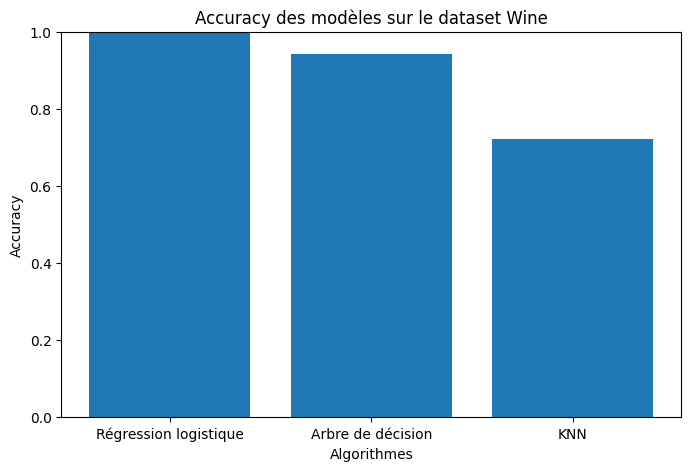

In [29]:
noms = [nom for nom, score in classement_wine]
scores = [score for nom, score in classement_wine]

plt.figure(figsize=(8, 5))

plt.bar(noms, scores)

plt.title("Accuracy des modèles sur le dataset Wine")
plt.xlabel("Algorithmes")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

### Lecture du graphique

La régression logistique domine clairement ce premier classement.

L'écart observé avec KNN est particulièrement important, ce qui confirme les résultats obtenus précédemment sous forme numérique.

In [30]:
from sklearn.metrics import confusion_matrix

### Matrice de confusion

La matrice de confusion permet de visualiser non seulement le nombre d'erreurs réalisées par le modèle, mais également leur nature.

Les valeurs situées sur la diagonale correspondent aux prédictions correctes.

Les valeurs situées en dehors de la diagonale représentent les erreurs de classification.

In [31]:
champion = LogisticRegression(max_iter=10000)

champion.fit(
    X_train_wine,
    y_train_wine
)

predictions = champion.predict(
    X_test_wine
)

matrice = confusion_matrix(
    y_test_wine,
    predictions
)

print(matrice)

[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


### Analyse de la matrice de confusion

La matrice de confusion obtenue est parfaitement diagonale.

Les 36 observations du jeu de test ont été correctement classées par la régression logistique :

- 14 prédictions correctes pour la classe 0 ;
- 14 prédictions correctes pour la classe 1 ;
- 8 prédictions correctes pour la classe 2.

Aucune erreur de classification n'a été observée sur ce découpage du dataset Wine.

Ce résultat explique l'accuracy de 100 % obtenue précédemment. Il montre également que les trois classes sont très bien séparées dans l'espace des caractéristiques utilisé par le modèle.

## Phase 7 : Influence du scaling

Certains algorithmes sont sensibles à l'échelle des variables tandis que d'autres le sont beaucoup moins.

Nous allons comparer les performances obtenues avant et après normalisation afin d'observer quels modèles profitent réellement de cette transformation.

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
def comparer_scaling(modeles, X_train, X_test, y_train, y_test):

    resultats = []

    for nom, modele in modeles.items():

        score_brut = entrainer_et_evaluer(
            modele,
            X_train,
            X_test,
            y_train,
            y_test
        )

        scaler = StandardScaler()

        X_train_scale = scaler.fit_transform(X_train)
        X_test_scale = scaler.transform(X_test)

        score_scale = entrainer_et_evaluer(
            modele,
            X_train_scale,
            X_test_scale,
            y_train,
            y_test
        )

        gain = score_scale - score_brut

        resultats.append(
            (
                nom,
                score_brut,
                score_scale,
                gain
            )
        )

    resultats.sort(
        key=lambda x: x[3],
        reverse=True
    )

    return resultats

In [34]:
modeles = {
    "Régression logistique": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(),
    "Arbre de décision": DecisionTreeClassifier(random_state=42)
}

resultats_scaling = comparer_scaling(
    modeles,
    X_train_wine,
    X_test_wine,
    y_train_wine,
    y_test_wine
)

for nom, brut, scale, gain in resultats_scaling:
    print(
        f"{nom:<25} "
        f"Brut={brut:.2%} "
        f"Scalé={scale:.2%} "
        f"Gain={gain:.2%}"
    )

KNN                       Brut=72.22% Scalé=94.44% Gain=22.22%
Régression logistique     Brut=100.00% Scalé=100.00% Gain=0.00%
Arbre de décision         Brut=94.44% Scalé=94.44% Gain=0.00%


### Effet du scaling

Les résultats montrent que tous les algorithmes ne réagissent pas de la même manière à la normalisation des données.

Le gain le plus important est observé sur KNN :

- Accuracy brute : 72.22 %
- Accuracy après scaling : 94.44 %
- Gain : +22.22 %

À l'inverse, l'arbre de décision et la régression logistique conservent exactement les mêmes performances.

Ce comportement est cohérent avec leur fonctionnement. KNN repose directement sur le calcul de distances entre observations et est donc fortement influencé par l'échelle des variables. Les arbres de décision, eux, réalisent des découpages par seuils et sont beaucoup moins sensibles à ce problème.

## Démonstration d'une fuite de données

Nous allons volontairement appliquer le scaler sur l'ensemble du dataset avant le découpage train/test.

Cette méthode est incorrecte mais permet d'illustrer le phénomène de data leakage.

In [35]:
scaler = StandardScaler()

X_wine_scale_triche = scaler.fit_transform(X_wine)

X_train_triche, X_test_triche, y_train_triche, y_test_triche = train_test_split(
    X_wine_scale_triche,
    y_wine,
    test_size=0.2,
    random_state=42
)

In [36]:
score_triche = entrainer_et_evaluer(
    LogisticRegression(max_iter=10000),
    X_train_triche,
    X_test_triche,
    y_train_triche,
    y_test_triche
)

print(score_triche)

1.0


### Résultat de la démonstration

Dans cette expérience, la fuite de données n'a entraîné aucune amélioration des performances.

Le score obtenu avec la méthode correcte était déjà de 100 %, et le score obtenu après la fuite de données reste également de 100 %.

L'absence de différence ne signifie cependant pas que la pratique est acceptable. Le problème du data leakage est méthodologique : le modèle bénéficie d'informations provenant du jeu de test, ce qui fausse l'évaluation.

Sur d'autres datasets ou avec d'autres algorithmes, cette erreur peut conduire à des gains artificiels beaucoup plus importants et donner l'illusion qu'un modèle est meilleur qu'il ne l'est réellement.

### Expérimentation complémentaire

La démonstration précédente n'a montré aucun effet visible de la fuite de données avec la régression logistique.

Par curiosité, le même test est réalisé avec KNN afin d'observer si un algorithme davantage sensible à la structure des données réagit différemment.

In [38]:
scaler = StandardScaler()

X_wine_scale_triche = scaler.fit_transform(X_wine)

X_train_triche, X_test_triche, y_train_triche, y_test_triche = train_test_split(
    X_wine_scale_triche,
    y_wine,
    test_size=0.2,
    random_state=42
)

score_knn_triche = entrainer_et_evaluer(
    KNeighborsClassifier(),
    X_train_triche,
    X_test_triche,
    y_train_triche,
    y_test_triche
)

print(score_knn_triche)

0.9444444444444444


Le score obtenu avec la méthode correcte et celui obtenu avec la méthode contenant une fuite de données sont identiques.

Dans ce cas précis, la fuite de données n'a donc pas eu d'impact visible sur l'accuracy.

Cela ne rend pas la méthode valide pour autant : le problème vient du fait que le jeu de test influence le prétraitement, ce qui fausse le cadre expérimental.